In [1]:
import cme.decision_models.confidence_accumulation as ca
import numpy as np
import scipy.stats as stats
import pandas as pd
import seaborn as sns
import numpyro as npy
import numpyro.distributions as dist
from cme.utils import common_utils as cu
import jax
from jax import config
config.update("jax_enable_x64", False)

In [2]:
n_states, start_width, threshold, measurement_prob, delta, mu, sigma, I, J = 7, 3, 1, 1, 1, np.asarray([[2]]), np.asarray([[1]]), 1, 5
model_type, transition_type = "Markov", "TIMESTEP"

In [3]:
intensity_matrix = ca.get_intensity_matrix(n_states, mu, sigma, model_type=model_type)
phi_0 = ca._get_initial_state(n_states, start_width,model_type=model_type, prior_type="Uniform")
intensity_matrix, phi_0

(Array([[[[-1. , -0.5,  0. ,  0. ,  0. ,  0. ,  0. ],
          [ 1. , -1. , -0.5,  0. ,  0. ,  0. ,  0. ],
          [ 0. ,  1.5, -1. , -0.5,  0. ,  0. ,  0. ],
          [ 0. ,  0. ,  1.5, -1. , -0.5,  0. ,  0. ],
          [ 0. ,  0. ,  0. ,  1.5, -1. , -0.5,  0. ],
          [ 0. ,  0. ,  0. ,  0. ,  1.5, -1. ,  1. ],
          [ 0. ,  0. ,  0. ,  0. ,  0. ,  1.5, -1. ]]]], dtype=float32),
 Array([[[[0.14285715],
          [0.14285715],
          [0.14285715],
          [0.14285715],
          [0.14285715],
          [0.14285715],
          [0.14285715]]]], dtype=float32))

In [4]:
jax.jacrev(ca.get_intensity_matrix, allow_int=True)(n_states, mu, sigma, model_type).size

49

In [5]:
Mc, Mw, Mn = ca._get_measurement_matrix(n_states, threshold, prob=measurement_prob, model_type = model_type)
Mc

Array([[0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1.]], dtype=float32)

In [6]:

t = np.asarray([[4.5]]) #t_s #
phi_t = ca.perform_state_transition(intensity_matrix=intensity_matrix, RT_s=t, RA_s = None, delta=delta, 
Mc = Mc, Mn = Mn, Mw = Mw, phi_0=phi_0, 
transition_type=transition_type, likelihood_type="SINGLE")

intensity_matrix.size, phi_t.size, (phi_t.size * phi_t.itemsize) / 1000000 # to get MB

(49, 7, 2.8e-05)

In [7]:
phi_jac = jax.jacfwd(ca.perform_state_transition)\
    (intensity_matrix, t, None, 
     Mc, Mw, Mn, 
     phi_0, delta, 
     transition_type, "SINGLE")
intensity_matrix.size, phi_jac.size, (phi_jac.size * phi_jac.itemsize) / 1000000 # to get MB

(49, 343, 0.001372)

In [8]:
intensity_matrix.shape, phi_t.shape, phi_jac.shape

((1, 1, 7, 7), (1, 1, 7, 1), (1, 1, 7, 1, 1, 1, 7, 7))

In [9]:
import jax.scipy as sci

In [10]:
ns=np.ceil(t/delta)

def perform_state_transition(intensity_matrix, RT_s, RA_s, Mc, Mw, Mn, phi_0, delta, transition_type="RT|TIMESTEP", likelihood_type="SINGLE|JOINT"):
     
    #ns=np.floor(RT/delta) # uncomment to include all response time
    
    T_delta = sci.linalg.expm(intensity_matrix * delta)

    # uncomment to include all response time
    # T_delta_remaining = sci.linalg.expm(intensity_matrix * ((RT_remaining[...,None,None]) if not npx.isscalar(RT_remaining) else (RT_remaining)))
    T_t = ca._timestep_transition_matrix(ns, T_delta, Mn)  #uncomment if fails
    return T_t

In [11]:
fn = jax.jacrev(perform_state_transition)
jax.jit(fn, static_argnames=["transition_type", "likelihood_type"]).lower(intensity_matrix, t, None, 
     Mc, Mw, Mn, 
     phi_0, delta, transition_type, "SINGLE"
     ).cost_analysis()

{'flops': 676663.0,
 'transcendentals': 2.0,
 'bytes accessed': 1520686.0,
 'optimal_seconds': -5.0,
 'utilization0{}': 520.4910888671875,
 'utilization1{}': 232.0,
 'bytes accessed0{}': 588415.0,
 'bytes accessed1{}': 240237.0,
 'bytes accessedout{}': 691644.0,
 'utilization9{}': 6.0,
 'utilization7{}': 7.0,
 'bytes accessed3{}': 3.0,
 'utilization8{}': 7.0,
 'utilization12{}': 2.0,
 'utilization10{}': 2.0,
 'bytes accessed7{}': -4.0,
 'utilization6{}': 13.0,
 'utilization13{}': 2.0,
 'utilization2{}': 66.0,
 'bytes accessed9{}': -4.0,
 'utilization4{}': 19.0,
 'bytes accessed6{}': -4.0,
 'bytes accessed5{}': -4.0,
 'bytes accessed2{}': 379.0,
 'utilization5{}': 17.0,
 'utilization3{}': 27.0,
 'bytes accessed8{}': -4.0,
 'utilization11{}': 2.0}

In [12]:
phi_jac = jax.jacrev(ca.perform_state_transition)\
    (intensity_matrix, t, None, 
     Mc, Mw, Mn, 
     phi_0, delta, 
     transition_type, "SINGLE")
intensity_matrix.size, phi_jac.size, (phi_jac.size * phi_jac.itemsize) / 1000000 # to get MB

(49, 343, 0.001372)

In [13]:
jax.jacfwd(jax.jacrev(ca.perform_state_transition))\
    (intensity_matrix, t, None, 
     Mc, Mw, Mn, 
     phi_0, delta, 
     transition_type, "SINGLE").size

16807

In [14]:
jax.jacrev(ca.likelihood)(intensity_matrix, phi_0, delta, t, 
                          np.asarray([[1]]),Mc, Mw, Mn,transition_type,"SINGLE", 
                          model_type).size

49

In [15]:
fn = jax.jacrev(ca.likelihood)
jax.jit(fn, static_argnames=["transition_type", "likelihood_type", "model_type"]).lower(
    intensity_matrix, phi_0, delta, t, 
    np.asarray([[1]]),Mc, Mw, Mn,transition_type,"SINGLE", 
    model_type
     ).cost_analysis()

TracerArrayConversionError: The numpy.ndarray conversion method __array__() was called on traced array with shape float32[1,1]
The error occurred while tracing the function likelihood at /home/axon/rkm160630/ritesh/computational_models_of_reasoning/cme/decision_models/confidence_accumulation.py:439 for jit. This concrete value was not available in Python because it depends on the values of the arguments delta and RT_s.
See https://jax.readthedocs.io/en/latest/errors.html#jax.errors.TracerArrayConversionError

In [16]:
import itertools as iter
n_states_arr, start_width_arr, delta, measurement_prob,  = [11, 51, 101], [2, 7, 11], 0.5, 0.8
threshold, measurement_prob, drift_rate, diffusion_rate = 1, 1, np.tile(1,(I,1)), np.tile(2,(I,1))
#model_type = "Quantum"
#transition_type="RT"
I_arr, J_arr = [20, 200, 2000], [50] #,1000,10000
transition_type_arr = ["TIMESTEP"]#, "TIMESTEP"]
model_type_arr = ["Markov", "Quantum"]
df_memory = []
for (n_states, start_width), (I, J, transition_type, model_type) in iter.product(zip(n_states_arr, start_width_arr), iter.product(I_arr, J_arr, transition_type_arr, model_type_arr)):
    print(n_states, start_width, I, J, transition_type, model_type)
    
    mu, sigma = np.tile(1,(I,1)), np.tile(2,(I,1))
    Mc, Mw, Mn = ca._get_measurement_matrix(n_states, threshold, prob=measurement_prob, model_type = model_type)
    phi_0 = ca._get_initial_state(n_states, start_width, model_type=model_type, prior_type="Uniform")
    
    random_ts = dist.Uniform(delta, 40/delta).sample(key=cu.get_rng(), sample_shape=(I,J))
    
    intensity_matrix = ca.get_intensity_matrix(n_states, mu, sigma, model_type=model_type)
    
    fn_g = jax.jacrev(perform_state_transition, holomorphic=True if model_type=="Quantum" else False)
    fn_g_jit = jax.jit(fn_g, static_argnames=["delta", "transition_type", "likelihood_type"])
    
    #phi_jac = fn_jit \
    #(intensity_matrix, t, None, 
    # Mc, Mw, Mn, 
    # phi_0, delta, 
    # transition_type, "SINGLE")

    cost_st_tr_g = fn_g_jit.lower(intensity_matrix, t, None, 
            Mc, Mw, Mn, 
            phi_0, delta, transition_type, "SINGLE"
            ).cost_analysis()
    

    
    fn = perform_state_transition
    fn_jit = jax.jit(fn, static_argnames=["delta", "transition_type", "likelihood_type"])
    
    #phi_jac = fn_jit \
    #(intensity_matrix, t, None, 
    # Mc, Mw, Mn, 
    # phi_0, delta, 
    # transition_type, "SINGLE")

    cost_st_tr = fn_jit.lower(intensity_matrix, t, None, 
            Mc, Mw, Mn, 
            phi_0, delta, transition_type, "SINGLE"
            ).cost_analysis()
                    
    df_t = pd.DataFrame({  
        "Model":model_type,
        "Transition":"External" if transition_type == "RT" else "Internal",
        "I":I,
        "J":J,
        "States":n_states,
        "bytes_accessed_g": [cost_st_tr_g["bytes accessed"] / 1000000000], # to get GB
        "flops_g": [cost_st_tr_g["flops"]/ 1000000000] , # to get gigaflops

        "bytes_accessed": [cost_st_tr["bytes accessed"] / 1000000000], # to get GB
        "flops": [cost_st_tr["flops"]/ 1000000000] , # to get gigaflops

    #    "matrix_orig":[intensity_matrix.size], 
    #    "matrix_jac":[phi_jac.size], 
    #    "matrix_memory":[(intensity_matrix.size * phi_jac.itemsize) / 1000000],
    #    "jac_memory":[(phi_jac.size * phi_jac.itemsize) / 1000000] # to get MB
    })
    print(cost_st_tr["bytes accessed"] / 1000000000, cost_st_tr_g["bytes accessed"] / 1000000000)
    #print(intensity_matrix.size, phi_jac.size)
    df_memory.append(df_t)
df_memory = pd.concat(df_memory)
df_memory

11 2 20 50 TIMESTEP Markov
0.002017715 6.161708544
11 2 20 50 TIMESTEP Quantum
0.003929751 12.49832448
11 2 200 50 TIMESTEP Markov
0.019733316 612.938088448
11 2 200 50 TIMESTEP Quantum
0.038469592 1243.437858816
11 2 2000 50 TIMESTEP Markov
0.196889248 61261.534461952
11 2 2000 50 TIMESTEP Quantum
0.383867968 124279.91187456
51 7 20 50 TIMESTEP Markov
0.042464276 2845.780475904
51 7 20 50 TIMESTEP Quantum
0.083540464 5772.727549952
51 7 200 50 TIMESTEP Markov
0.41538448 283208.197341184
51 7 200 50 TIMESTEP Quantum
0.817905536 574534.486851584
51 7 2000 50 TIMESTEP Markov
4.1445888 28307117.983137794
51 7 2000 50 TIMESTEP Quantum
8.161562624 57426057.79966362
101 11 20 50 TIMESTEP Markov
0.166255392 43772.226306048
101 11 20 50 TIMESTEP Quantum
0.327350784 88793.096912896
101 11 200 50 TIMESTEP Markov
1.626322432 4356221.045833728
101 11 200 50 TIMESTEP Quantum
3.20495872 8837313.97083136
101 11 2000 50 TIMESTEP Markov
16.226991104 435412067.79769653
101 11 2000 50 TIMESTEP Quantum
31

,Model,Transition,I,J,States,bytes_accessed_g,flops_g,bytes_accessed,flops
0,Markov,Internal,20,50,11,6.161709e+00,3.582549e+00,0.002018,0.000803
0,Quantum,Internal,20,50,11,1.249832e+01,3.600125e+00,0.003930,0.000810
0,Markov,Internal,200,50,11,6.129381e+02,3.552335e+02,0.019733,0.007945
0,Quantum,Internal,200,50,11,1.243438e+03,3.569906e+02,0.038470,0.008018
0,Markov,Internal,2000,50,11,6.126153e+04,3.549313e+04,0.196889,0.079369
0,Quantum,Internal,2000,50,11,1.242799e+05,3.566882e+04,0.383868,0.080098
0,Markov,Internal,20,50,51,2.845780e+03,7.121388e+03,0.042464,0.071944
0,Quantum,Internal,20,50,51,5.772728e+03,7.129506e+03,0.083540,0.072103
0,Markov,Internal,200,50,51,2.832082e+05,7.058979e+05,0.415384,0.711995
0,Quantum,Internal,200,50,51,5.745345e+05,7.067098e+05,0.817906,0.713558


phi_0 = ca._get_initial_state(n_states, start_width, model_type=model_type, prior_type="Uniform")
    random_ts = dist.Uniform(delta, 40/delta).sample(key=cu.get_rng(), sample_shape=(I,J))
    intensity_matrix = ca.get_intensity_matrix(n_states, mu, sigma, model_type=model_type)
    phi_jac = jax.jacfwd(ca.perform_state_transition, holomorphic=True if model_type=="Quantum" else False)(intensity_matrix, random_ts, None, delta, 
    Mc, Mn, Mw, phi_0, transition_type, "SINGLE")

f = sns.relplot(
            df_memory.melt(id_vars=df_memory.columns.drop(["bytes_accessed_g", "bytes_accessed"]), var_name="Memory(GB)") \
            .assign(**{"Memory(GB)": lambda df: df["Memory(GB)"].map({"bytes_accessed_g":"Jacobian of Transition Fn", "bytes_accessed":"Transition Function"})})
            ,
style="States",
y="value",
col="Model",
x="I",
hue="Memory(GB)",
kind="line", facet_kws={"sharey":True}
)
f.set(yscale="log", xscale="log")
f.set_ylabels("Memory (GB)")
f.set_xlabels("Number of Participants")
f.set_titles(col_template="{col_name}")

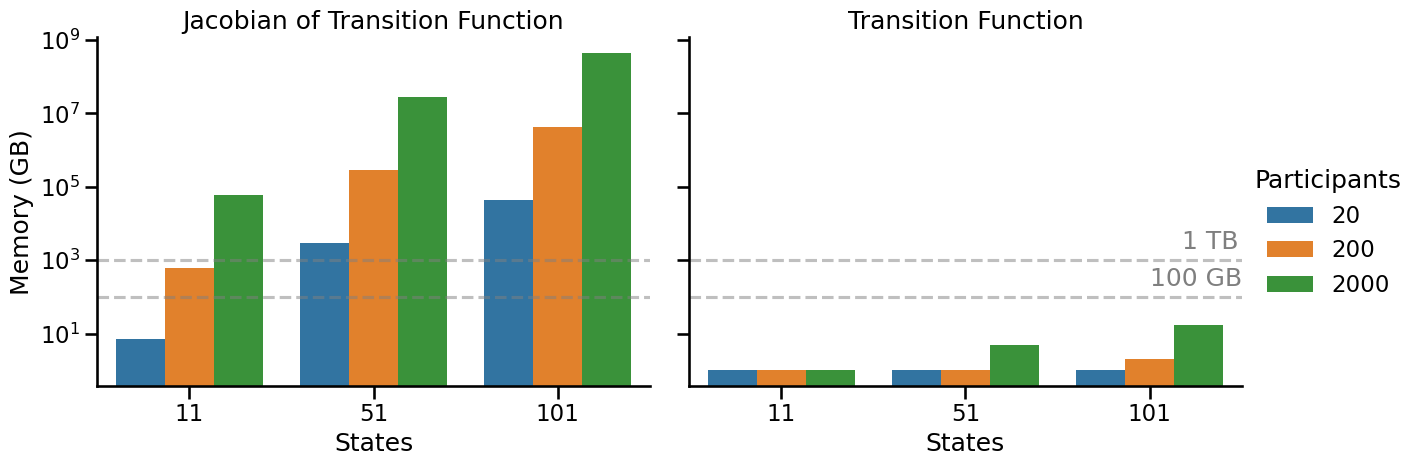

In [24]:
with sns.plotting_context("talk"):
    f = sns.catplot(
                df_memory.query("Model=='Markov'").melt(id_vars=df_memory.columns.drop(["bytes_accessed_g", "bytes_accessed"]), var_name="Function") \
                .assign(**{"Function": lambda df: df["Function"].map({"bytes_accessed_g":"Jacobian of Transition Function", "bytes_accessed":"Transition Function"})})
                .assign(I = lambda df: df.I.astype(str), value = lambda df: np.ceil(df.value)),
    x="States",
    y="value",
    hue="I",
    col="Function", aspect=1.3,
    kind="bar", #facet_kws={"sharey":True}
    )
    f.set(yscale="log")#, xscale="log")
    f.set_ylabels("Memory (GB)")
    f.set_xlabels("States")
    f.set_titles(col_template="{col_name}")
    f.refline(y=1000, alpha=0.5)
    f.refline(y=100, alpha=0.5)
    f.legend.set_title("Participants")
    f.axes[0,1].text(y=200, x=2, s="100 GB", alpha=0.5)
    f.axes[0,1].text(y=2000, x=2.175, s="1 TB", alpha=0.5)

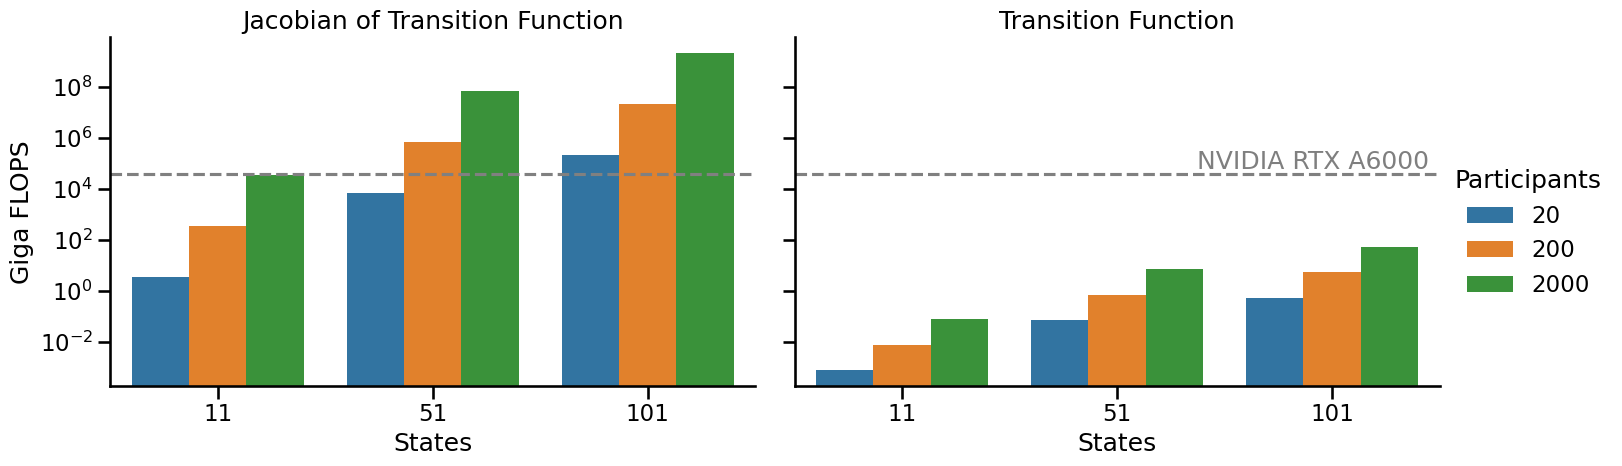

In [31]:
with sns.plotting_context("talk"):
    f = sns.catplot(
                df_memory.query("Model=='Markov'").melt(id_vars=df_memory.columns.drop(["flops_g", "flops"]), var_name="FLOPS") \
                .assign(FLOPS = lambda df: df.FLOPS.map({"flops_g":"Jacobian of Transition Function", "flops":"Transition Function"})) 
                .assign(I = lambda df: df.I.astype(str))
                ,
    x="States",
    y="value",
    hue="I", #col_order=["Transition Function", "Jacobian of Transition Function"],
    col="FLOPS",
    kind="bar", aspect=1.5
    )
    f.set(yscale="log")
    f.set_ylabels("Giga FLOPS")
    f.set_xlabels("States")
    f.set_titles(col_template="{col_name}")
    f.refline(y=38000)
    f.legend.set_title("Participants")
    f.axes[0,1].text(y=60000, x=1.37, s="NVIDIA RTX A6000", alpha=0.5)

f = sns.relplot(
            df_memory.melt(id_vars=df_memory.columns.drop(["flops_g", "flops"]), var_name="FLOPS") \
            .assign(FLOPS = lambda df: df.FLOPS.map({"flops_g":"Jacobian of Transition Fn", "flops":"Transition Function"})) 
            ,
style="States",
y="value",
col="Model",
x="I",
hue="FLOPS",
kind="line", facet_kws={"sharey":True}
)
f.set(yscale="log")